# Patchscopes: Using the Model to Explain Itself

**Survey Reference:** Section 8.4 - Patchscopes ([Ghandeharioun et al., 2024](https://arxiv.org/abs/2401.06102))

## Overview

**Patchscopes** use the language model itself to decode and explain its intermediate representations. Instead of training external probes, we patch hidden states into prompts that ask the model to describe what it represents.

### The Core Idea

1. Extract hidden state $h$ from the source model at layer $l_S$ and position $i$
2. Patch $h$ into a **target prompt** at position $j$ and layer $l_T$
3. Read out the model's prediction -- it now reflects the injected representation

### Patchscope Configuration

A Patchscope is defined by the tuple $(S, i, l_S, T, j, l_T, f)$ where:
- $S$ = source prompt, $i$ = source position, $l_S$ = source layer
- $T$ = target prompt, $j$ = target position, $l_T$ = target layer
- $f$ = optional mapping function between source and target representations

The **logit lens** is a special case: $S = T$, $i = j$, $l_T = L-1$ (last layer), $f = \text{id}$.

## Learning Objectives

1. Understand the patchscopes framework and its formal configuration
2. Implement patchscopes using forward hooks in PyTorch
3. Decode token identity at each layer (logit lens as patchscope)
4. Visualize how predictions evolve across layers
5. Evaluate reliability against known ground truth via source-target layer sweeps

In [1]:
%pip install torch transformers matplotlib numpy --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Setup

GPT-2 Medium: 345M params, 24 layers, 1024-dim hidden states, 50257 token vocabulary.

In [3]:
model_name = "gpt2-medium"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

n_layers = model.config.n_layer
hidden_size = model.config.n_embd
print(f"Model: {model_name}")
print(f"Layers: {n_layers}, Hidden size: {hidden_size}")

Model: gpt2-medium
Layers: 24, Hidden size: 1024


In [4]:
def extract_hidden_states(model, tokenizer, text):
    """Run model and return all hidden states."""
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return outputs.hidden_states, outputs.logits, inputs

source = "The capital of France is Paris"
hidden_states, logits, inputs = extract_hidden_states(model, tokenizer, source)
print(f"Source: '{source}'")
print(f"Tokens: {[tokenizer.decode([t]) for t in inputs['input_ids'][0]]}")
print(f"Hidden states: {len(hidden_states)} layers, shape={hidden_states[0].shape}")
print(f"Hidden state norm at layer 20, last pos: {hidden_states[20][0, -1].norm():.2f}")

Source: 'The capital of France is Paris'
Tokens: ['The', ' capital', ' of', ' France', ' is', ' Paris']
Hidden states: 25 layers, shape=torch.Size([1, 6, 1024])
Hidden state norm at layer 20, last pos: 367.98


## 2. The Patchscope Mechanism

The core operation:
1. Run the **source** prompt, extract hidden state $h$ at layer $l_S$, position $i$
2. Run the **target** prompt, but at layer $l_T$ **replace** the hidden state at position $j$ with $h$
3. Read out the model's prediction -- it now reflects the injected representation

We use a **pre-hook** that patches the *input* to layer $l_T$, so all attention heads in that layer and all subsequent layers see the patched value. This is essential because a post-hook would only affect layers after $l_T$, losing one layer of processing.

In [5]:
class PatchscopeHook:
    """Pre-hook that patches a hidden state at a specific position.
    
    Patches the INPUT to a transformer layer, so all attention heads
    in that layer (and subsequent layers) see the injected representation.
    """
    def __init__(self, patch_position, patch_value):
        self.patch_position = patch_position
        self.patch_value = patch_value

    def __call__(self, module, args):
        hidden_states = args[0]
        seq_len = hidden_states.shape[1]
        if seq_len == 1:
            return args
        hidden_states[0, self.patch_position, :] = self.patch_value
        return (hidden_states,) + args[1:]


def inspect(
    model, tokenizer, source_text, target_prompt,
    layer_source, layer_target, position_source, position_target,
    generation_mode=False, max_new_tokens=10,
):
    """Core patchscope: extract from source, patch into target.
    
    Args:
        source_text: prompt to extract representation from
        target_prompt: prompt to patch into
        layer_source: layer to extract from (0-indexed)
        layer_target: layer to patch at (0-indexed)
        position_source: token position in source (-1 for last)
        position_target: token position in target (-1 for last)
        generation_mode: True=generate tokens, False=single next-token prediction
    
    Returns:
        generation_mode=True: generated text (new tokens only)
        generation_mode=False: (token_str, probability)
    """
    inp_source = tokenizer(source_text, return_tensors="pt").to(device)
    with torch.no_grad():
        out_source = model(**inp_source, output_hidden_states=True)
    # hidden_states[0]=embeddings, [l+1]=output of layer l
    h = out_source.hidden_states[layer_source + 1][0, position_source, :]

    inp_target = tokenizer(target_prompt, return_tensors="pt").to(device)
    target_len = inp_target["input_ids"].shape[1]
    abs_pos = position_target if position_target >= 0 else target_len + position_target

    hook = PatchscopeHook(abs_pos, h)
    handle = model.transformer.h[layer_target].register_forward_pre_hook(hook)

    try:
        with torch.no_grad():
            if generation_mode:
                outputs = model.generate(
                    **inp_target, max_new_tokens=max_new_tokens,
                    do_sample=False, pad_token_id=tokenizer.eos_token_id,
                )
                result = tokenizer.decode(outputs[0][target_len:], skip_special_tokens=True)
            else:
                outputs = model(**inp_target)
                probs = torch.softmax(outputs.logits[0, -1, :], dim=0)
                prob, tok_id = torch.max(probs, dim=0)
                result = (tokenizer.decode([tok_id]), prob.item())
    finally:
        handle.remove()

    return result

print("Patchscope mechanism ready.")

Patchscope mechanism ready.


## 3. Token Identity via Patchscope 

The simplest patchscope configuration patches a hidden state from layer $l_S$ into the **last layer** of the **same prompt**. This is equivalent to the **logit lens** -- it decodes what the model "believes" at each intermediate layer.

Configuration: $S = T$ (same prompt), $l_T = L-1$ (last layer), $i = j$ (same position).

This works even on small models like GPT-2 because the final layer norm + unembedding naturally decode the patched representation.

In [6]:
def patchscope_logit_lens(model, tokenizer, source_text, position=-1):
    """Patchscope as logit lens: patch each layer's hidden state into the last layer."""
    inp = tokenizer(source_text, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inp, output_hidden_states=True)

    results = {}
    for layer in range(n_layers):
        h = out.hidden_states[layer + 1][0, position, :]
        inp_t = tokenizer(source_text, return_tensors="pt").to(device)
        hook = PatchscopeHook(position, h)
        handle = model.transformer.h[n_layers - 1].register_forward_pre_hook(hook)
        with torch.no_grad():
            out_t = model(**inp_t)
        handle.remove()
        probs = torch.softmax(out_t.logits[0, position, :], dim=0)
        prob, tok_id = torch.max(probs, dim=0)
        results[layer] = {"token": tokenizer.decode([tok_id]).strip(), "prob": prob.item()}

    return results

source = "The capital of France is"
results = patchscope_logit_lens(model, tokenizer, source)
print(f"Source: '{source}' (model should predict ' Paris')\n")
for layer, r in sorted(results.items()):
    print(f"  Layer {layer:2d}: predicted='{r['token']}' (prob={r['prob']:.3f})")

Source: 'The capital of France is' (model should predict ' Paris')

  Layer  0: predicted='not' (prob=0.001)
  Layer  1: predicted='not' (prob=0.007)
  Layer  2: predicted='paid' (prob=0.009)
  Layer  3: predicted='not' (prob=0.042)
  Layer  4: predicted='not' (prob=0.143)
  Layer  5: predicted='not' (prob=0.574)
  Layer  6: predicted='not' (prob=0.546)
  Layer  7: predicted='not' (prob=0.090)
  Layer  8: predicted='not' (prob=0.090)
  Layer  9: predicted='not' (prob=0.283)
  Layer 10: predicted='not' (prob=0.182)
  Layer 11: predicted='not' (prob=0.249)
  Layer 12: predicted='not' (prob=0.126)
  Layer 13: predicted='not' (prob=0.137)
  Layer 14: predicted='not' (prob=0.073)
  Layer 15: predicted='the' (prob=0.066)
  Layer 16: predicted='the' (prob=0.072)
  Layer 17: predicted='Paris' (prob=0.079)
  Layer 18: predicted='Paris' (prob=0.132)
  Layer 19: predicted='Paris' (prob=0.085)
  Layer 20: predicted='Paris' (prob=0.143)
  Layer 21: predicted='Paris' (prob=0.123)
  Layer 22: predict

## 4. Layer-by-Layer Visualization

We visualize how the model's internal "belief" about the next token evolves across layers using the logit-lens patchscope. This shows the progressive refinement of predictions through depth.

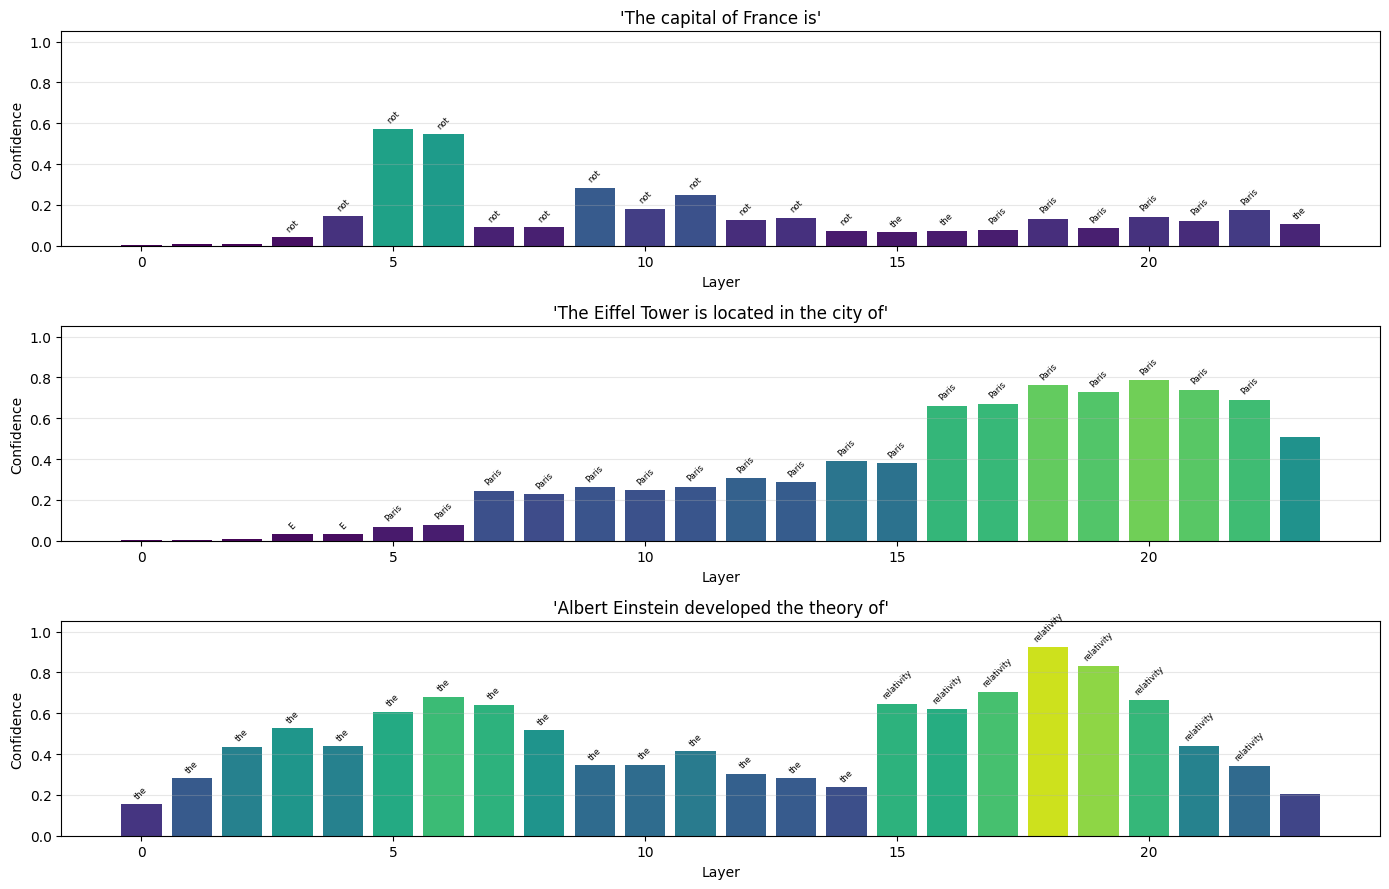

In [7]:
examples = [
    "The capital of France is",
    "The Eiffel Tower is located in the city of",
    "Albert Einstein developed the theory of",
]

fig, axes = plt.subplots(len(examples), 1, figsize=(14, 3 * len(examples)))
if len(examples) == 1:
    axes = [axes]

for idx, source in enumerate(examples):
    results = patchscope_logit_lens(model, tokenizer, source)
    layers = sorted(results.keys())
    probs = [results[l]["prob"] for l in layers]
    tokens = [results[l]["token"] for l in layers]

    ax = axes[idx]
    colors = plt.cm.viridis(np.array(probs))
    ax.bar(layers, probs, color=colors, edgecolor="none")
    ax.set_ylabel("Confidence")
    ax.set_xlabel("Layer")
    ax.set_title(f"'{source}'")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis="y")

    for i, (l, t) in enumerate(zip(layers, tokens)):
        if probs[i] > 0.03:
            ax.text(l, probs[i] + 0.02, t, ha="center", va="bottom", fontsize=6, rotation=45)

plt.tight_layout()
plt.show()

## 5. Source-Target Layer Sweep

A central experiment from the paper: vary both $l_S$ (source layer) and $l_T$ (target layer) and measure next-token recovery accuracy.

We patch from source position $i$ at layer $l_S$ into the same prompt at layer $l_T$, same position $i$. Expected patterns:
- **Late target layers** should work best (they apply fewer transformations to the patched state)
- **Diagonal** ($l_S = l_T$): works when both layers represent similar information
- **Bottom-right corner** ($l_S$ late, $l_T$ late): highest accuracy

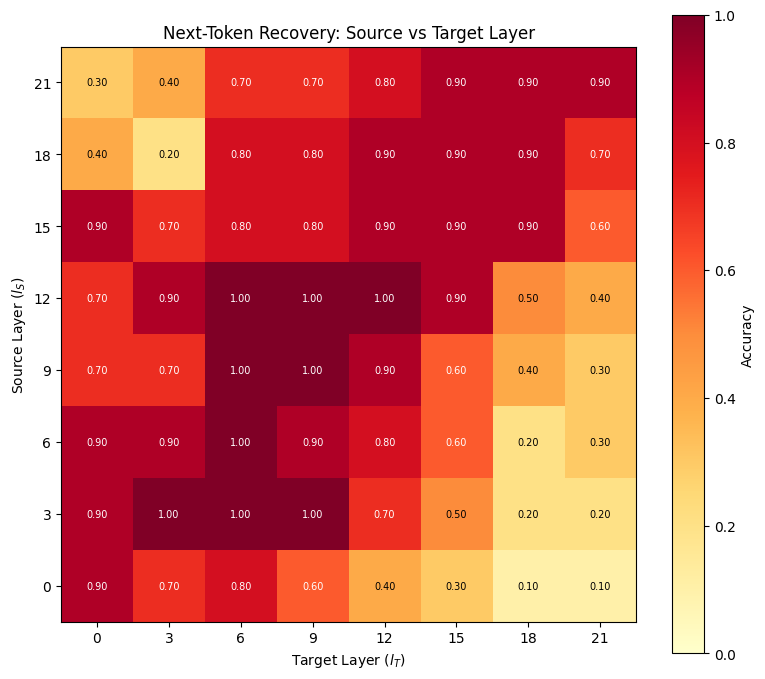

In [8]:
test_prompts = [
    "The capital of France is",
    "The largest ocean on Earth is the",
    "In 1969 humans first landed on the",
    "Albert Einstein was born in",
    "The Great Wall is located in",
    "Python is a popular programming",
    "The chemical symbol for water is",
    "The speed of light is approximately",
    "The first President of the United States was George",
    "Water is made of hydrogen and",
]

def layer_sweep_accuracy(model, tokenizer, test_prompts, step=3):
    """Next-token recovery accuracy for all (source, target) layer pairs."""
    layers_to_test = list(range(0, n_layers, step))
    n = len(layers_to_test)
    accuracy = np.zeros((n, n))
    counts = np.zeros((n, n))

    for text in test_prompts:
        inp = tokenizer(text, return_tensors="pt").to(device)
        if inp["input_ids"].shape[1] < 2:
            continue
        with torch.no_grad():
            out = model(**inp, output_hidden_states=True)
        _, orig_tok_id = torch.max(torch.softmax(out.logits[0, -1, :], dim=0), dim=0)

        for si, ls in enumerate(layers_to_test):
            h = out.hidden_states[ls + 1][0, -1, :]
            for ti, lt in enumerate(layers_to_test):
                inp_t = tokenizer(text, return_tensors="pt").to(device)
                hook = PatchscopeHook(-1, h)
                handle = model.transformer.h[lt].register_forward_pre_hook(hook)
                with torch.no_grad():
                    out_t = model(**inp_t)
                handle.remove()
                probs = torch.softmax(out_t.logits[0, -1, :], dim=0)
                _, patched_id = torch.max(probs, dim=0)
                accuracy[si, ti] += float(patched_id == orig_tok_id)
                counts[si, ti] += 1

    return np.divide(accuracy, counts, where=counts > 0), layers_to_test

sweep_accuracy, layers_tested = layer_sweep_accuracy(model, tokenizer, test_prompts, step=3)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sweep_accuracy, cmap="YlOrRd", vmin=0, vmax=1, origin="lower")
ax.set_xticks(range(len(layers_tested)))
ax.set_xticklabels(layers_tested)
ax.set_yticks(range(len(layers_tested)))
ax.set_yticklabels(layers_tested)
ax.set_xlabel("Target Layer ($l_T$)")
ax.set_ylabel("Source Layer ($l_S$)")
ax.set_title("Next-Token Recovery: Source vs Target Layer")
plt.colorbar(im, ax=ax, label="Accuracy")

for i in range(len(layers_tested)):
    for j in range(len(layers_tested)):
        ax.text(j, i, f"{sweep_accuracy[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if sweep_accuracy[i,j] > 0.5 else "black")

plt.tight_layout()
plt.show()

## 6. Reliability Evaluation

To measure patchscope reliability, we test against **known ground truth**: factual prompts where we know the correct next token.

We use the logit-lens patchscope (patch layer $l_S$'s state into the last layer of the same prompt) and check whether the top prediction matches the expected answer at each source layer.

In [9]:
ground_truth_prompts = [
    ("The capital of France is", " Paris"),
    ("The capital of Germany is", " Berlin"),
    ("The capital of Japan is", " Tokyo"),
    ("The capital of Italy is", " Rome"),
    ("The largest planet in our solar system is", " Jupiter"),
    ("The chemical symbol for gold is", " Au"),
    ("Water is made of hydrogen and", " oxygen"),
    ("The Great Wall is located in", " China"),
    ("The first President of the United States was George", " Washington"),
    ("In chess the most powerful piece is the", " queen"),
]

gt_accuracy = np.zeros(n_layers)
self_patch_accuracy = np.zeros(n_layers)
gt_count = 0

for source_text, expected_token in ground_truth_prompts:
    expected_id = tokenizer.encode(expected_token)[0]
    inp = tokenizer(source_text, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inp, output_hidden_states=True)

    # Original model prediction (for self-patching check)
    orig_probs = torch.softmax(out.logits[0, -1, :], dim=0)
    _, orig_tok_id = torch.max(orig_probs, dim=0)

    for layer in range(n_layers):
        h = out.hidden_states[layer + 1][0, -1, :]
        inp_t = tokenizer(source_text, return_tensors="pt").to(device)
        hook = PatchscopeHook(-1, h)
        handle = model.transformer.h[n_layers - 1].register_forward_pre_hook(hook)
        with torch.no_grad():
            out_t = model(**inp_t)
        handle.remove()
        probs = torch.softmax(out_t.logits[0, -1, :], dim=0)
        _, patched_id = torch.max(probs, dim=0)

        gt_accuracy[layer] += float(patched_id.item() == expected_id)
        self_patch_accuracy[layer] += float(patched_id.item() == orig_tok_id.item())

    gt_count += 1

gt_accuracy /= gt_count
self_patch_accuracy /= gt_count
print("Evaluation complete.")

Evaluation complete.


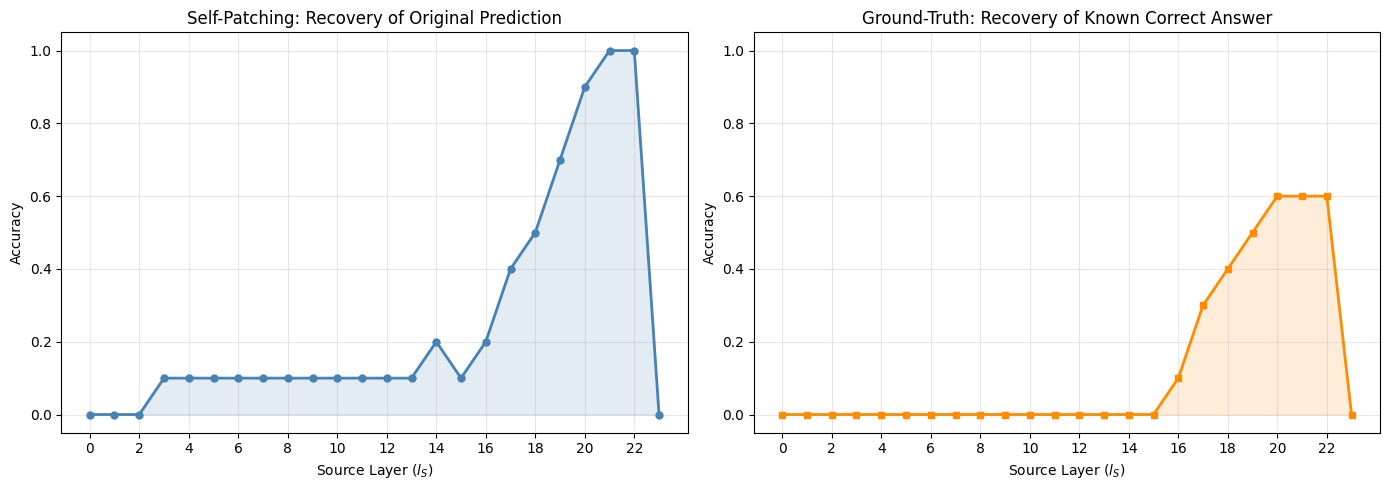

Ground-truth accuracy by layer quartile:
  Early      (layers  0- 5): 0.0%
  Mid-early  (layers  6-11): 0.0%
  Mid-late   (layers 12-17): 6.7%
  Late       (layers 18-23): 45.0%


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(n_layers), self_patch_accuracy, marker="o", linewidth=2, markersize=5, color="steelblue")
ax1.fill_between(range(n_layers), self_patch_accuracy, alpha=0.15, color="steelblue")
ax1.set_xlabel("Source Layer ($l_S$)")
ax1.set_ylabel("Accuracy")
ax1.set_title("Self-Patching: Recovery of Original Prediction")
ax1.set_ylim(-0.05, 1.05)
ax1.set_xticks(range(0, n_layers, 2))
ax1.grid(True, alpha=0.3)

ax2.plot(range(n_layers), gt_accuracy, marker="s", linewidth=2, markersize=5, color="darkorange")
ax2.fill_between(range(n_layers), gt_accuracy, alpha=0.15, color="darkorange")
ax2.set_xlabel("Source Layer ($l_S$)")
ax2.set_ylabel("Accuracy")
ax2.set_title("Ground-Truth: Recovery of Known Correct Answer")
ax2.set_ylim(-0.05, 1.05)
ax2.set_xticks(range(0, n_layers, 2))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

q = n_layers // 4
print("Ground-truth accuracy by layer quartile:")
for name, s, e in [("Early", 0, q), ("Mid-early", q, 2*q),
                    ("Mid-late", 2*q, 3*q), ("Late", 3*q, n_layers)]:
    print(f"  {name:10s} (layers {s:2d}-{e-1:2d}): {gt_accuracy[s:e].mean():.1%}")

## 7. Limitations and Caveats

1. **Prompt sensitivity:** Results depend heavily on prompt design. The logit-lens patchscope (same prompt, last layer) is the most robust configuration.

2. **Layer mismatch:** Patching early-layer states into early target layers produces noise because representations at different depths occupy different subspaces. Learned affine mappings $f$ can bridge this gap (tuned lens).

3. **Not ground truth:** The model's "reading" of its own representations is itself a model output -- it can hallucinate or reflect the target prompt's bias rather than the patched state.

4. **Model scale:** Many patchscope configurations (few-shot identity prompts, attribute extraction) require large models (6B+ parameters) to work reliably. Smaller models like GPT-2 work best with the logit-lens special case.

5. **Computational cost:** Each patchscope evaluation requires a full forward pass, making sweeps over all layer pairs expensive.

## Key Takeaways

1. **Patchscopes** ([Ghandeharioun et al., 2024](https://arxiv.org/abs/2401.06102)) provide a unified framework for inspecting LLM hidden representations by patching them into interpretive prompts.

2. **No training required:** Unlike probing classifiers, patchscopes work by leveraging the model's own generation capabilities.

3. **Subsumes prior methods:** The logit lens ($S=T$, $l_T=L-1$) and tuned lens (with learned $f$) are special cases of the patchscope framework.

4. **Flexible inspection:** Different target prompts enable different tasks -- token identity, attribute extraction, entity analysis, and more.

5. **Layer sensitivity:** Later source layers produce more reliable results, consistent with representations becoming "output-ready" with depth.



## References

- Ghandeharioun, A., Caciularu, A., Pearce, A., Dixon, L., & Geva, M. (2024). *Patchscopes: A Unifying Framework for Inspecting Hidden Representations of Language Models.* [arXiv:2401.06102](https://arxiv.org/abs/2401.06102)
- Original code: [github.com/PAIR-code/interpretability/patchscopes](https://github.com/PAIR-code/interpretability/tree/master/patchscopes/code)

## Next Steps

-> **05_probing_classifiers.ipynb**: Train external classifiers to probe representations